### Notebook 7: Stacking by group

We now have codes to group LFEs and look at the stacks from various groups.  This notebook summarises those codes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from obspy import UTCDateTime
import os,sys
import LFEAnalysis as lfeanalysis

lfeanalysis.reload_all(lfeanalysis)


### 1. Load and prepare the data

As usual, we first read in detections and the data.

In [2]:
# as before, we need to initialize an analysis object
lf=lfeanalysis.lfeanalyse(fnum=1,region='Guerrero',catalog='Frank2014',data_directory="/home/earthquakes2/homes/Julia/LFEAnalysis/DATA")

# and read the relevant detections
lf.read_detection_info()

# load the data
lf.read_data()

In [3]:
# normalise the seismograms
lf.normalize_data(single_norm=False)

# we may first need to discard any LFE intervals that contain NaNs, 
# as these will disrupt the filtering
lf.discard_data_with_nans()

# and bandpass filter
# we can filter the intervals with a 2-pass (non-causal) butterworth filter
# let's choose corners of 1 and 10 Hz
lf.filter_data(flm=[1,2])

### 2. Group events 

Next, we want to identify the slow slip events and group the LFEs in this family into early and late groups. 

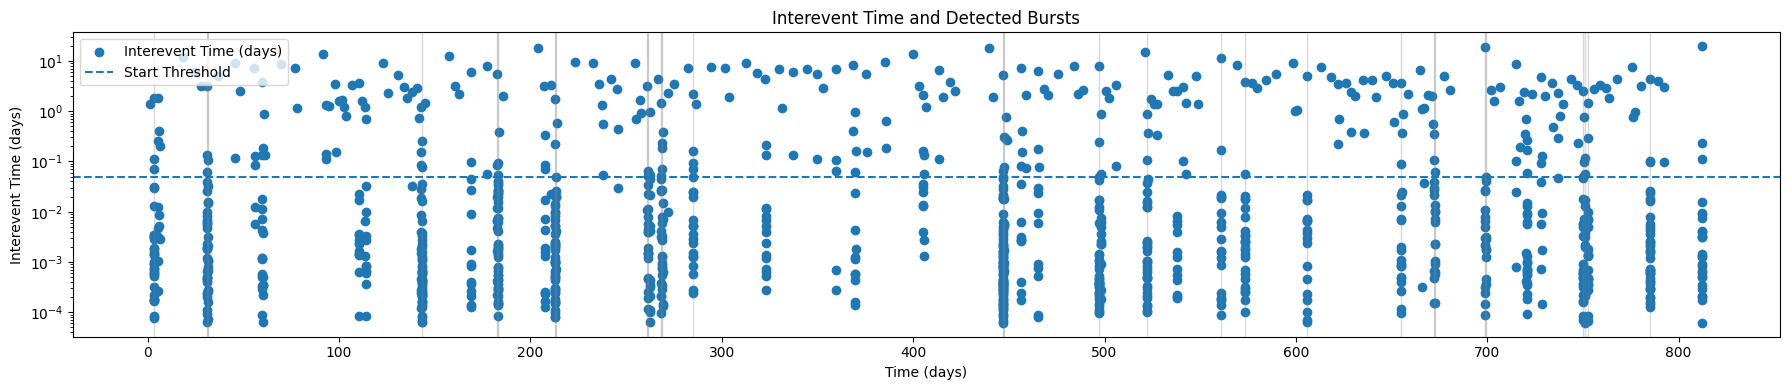

In [4]:
## Detect and divide bursts 

lf.detect_lfe_bursts_interevent(start_threshold = 0.05, end_threshold = 0.1, dmin=15)
lf.plot_lfe_bursts_interevent()
lf.split_events_by_detections()


### 3. Stack

Now we can go ahead and make stacks.

In [5]:
# stack for each group
lf.stack_by_group()

# and pick arrival times
lf.pick_stacks(minsnr=10)

In [6]:
print('The grouped stacks are saved in a dictionary lf.grpstk, with keys ',lf.grpstk.keys())
print('\nlf.grpstk[\'early\'] contains',lf.grpstk['early'])

The grouped stacks are saved in a dictionary lf.grpstk, with keys  dict_keys(['early', 'late'])

lf.grpstk['early'] contains 126 Trace(s) in Stream:

.ACAH..E | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.990000Z | 100.0 Hz, 8000 samples
...
(124 other traces)
...
.ZURI..Z | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.990000Z | 100.0 Hz, 8000 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]


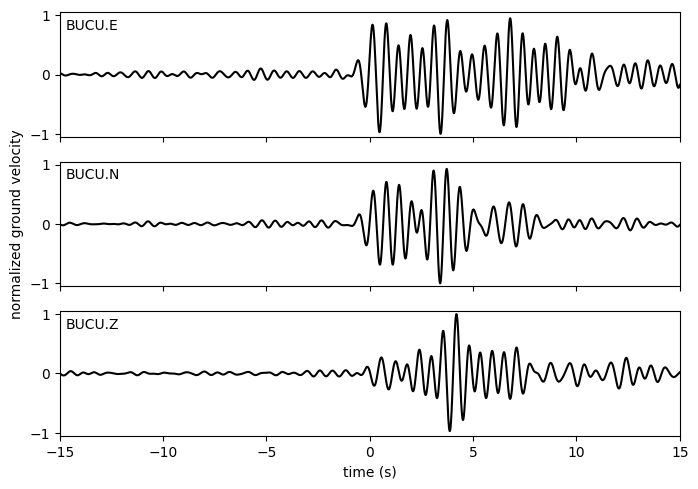

In [7]:
# we can plot the stack of all LFEs at station B926
p=lf.plot_stacks(stype='all',stn='BUCU')

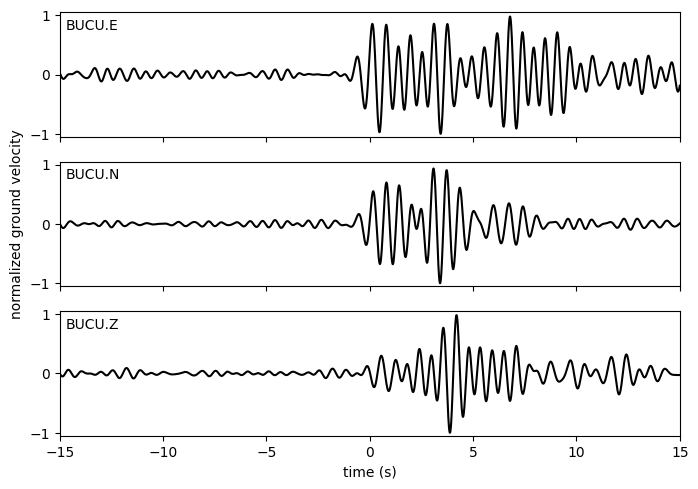

In [9]:
# we can look at the stack for one group
p=lf.plot_stacks(stype='early',Ns=1,stn='BUCU')

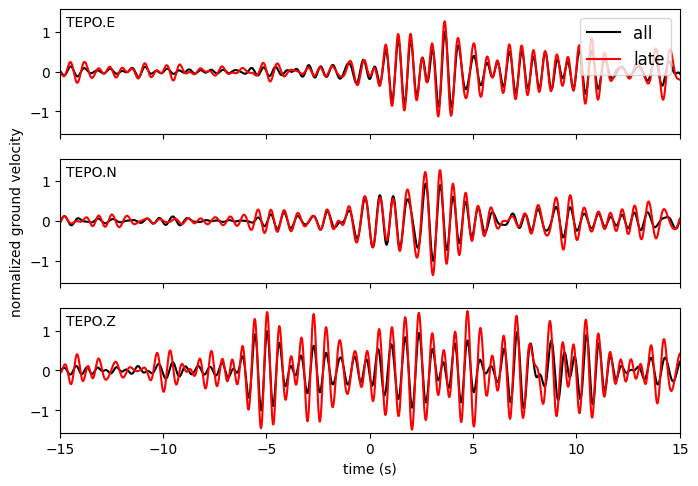

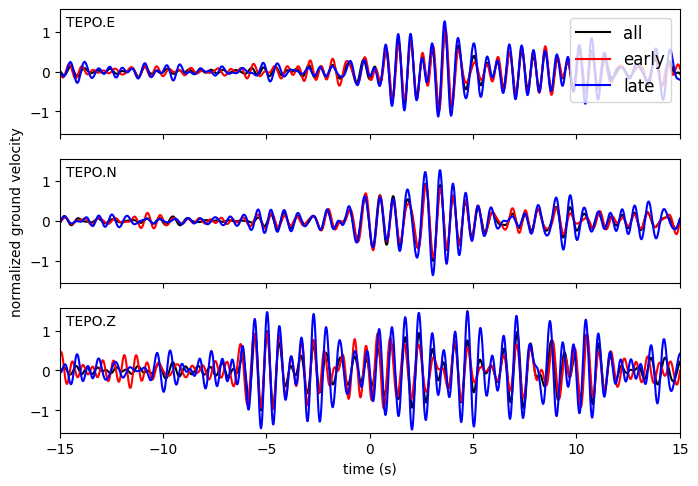

In [11]:
# and we could compare some of the stacks
p=lf.plot_stacks(stype='all',Ns=1,stn='TEPO',morestacks=['late'])

# plot early and late

p=lf.plot_stacks(stype='all',Ns=1,stn='TEPO',morestacks=['early','late'])

### 4. Note bootstrapped stacks

It may be useful to note that there are bootstrapped versions of the grouped stacks as well as bootstrapped versions of the total stack.

Stack with all events is in lf.totstk:  .SATA..E | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.990000Z | 100.0 Hz, 8000 samples

There are bootstrapped stacks including subsets of all events in lf.totstkb:  (8000, 30)


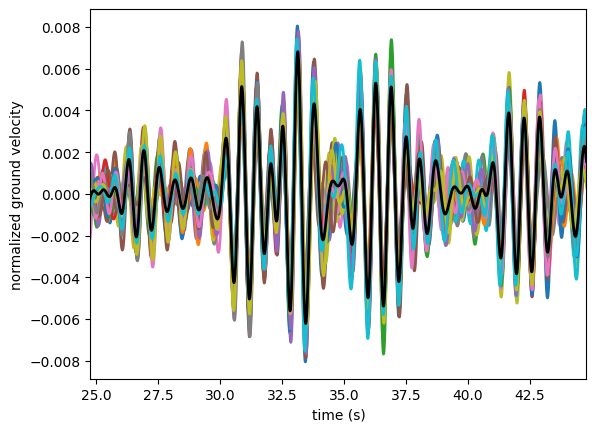

In [12]:
# let's look at the bootstrapped stacks for one station with good SNR
stn=np.random.choice(lf.stns_stack,1)[0]
# on the east component
chn='E'

# the trace with all the events
tr=lf.totstk.select(channel=chn,station=stn)[0]
print('Stack with all events is in lf.totstk: ',tr)

# the bootstrapped stacks
stkb=lf.totstkb['.'.join([stn,chn])]
print('\nThere are bootstrapped stacks including subsets of all events in lf.totstkb: ',stkb.shape)

plt.plot(tr.times(),stkb,linewidth=2,label='bootstrapped');
plt.plot(tr.times(),tr.data,color='k',linewidth=2,label='full stack');
plt.xlim(np.array([-5,15])+tr.stats.t0);
plt.xlabel('time (s)');
plt.ylabel('normalized ground velocity');

Stack with all events is in lf.grpstk:  .CASA..E | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.990000Z | 100.0 Hz, 8000 samples

There are bootstrapped stacks including subsets of the early events in lf.grpstkb['early']:  (8000, 30)


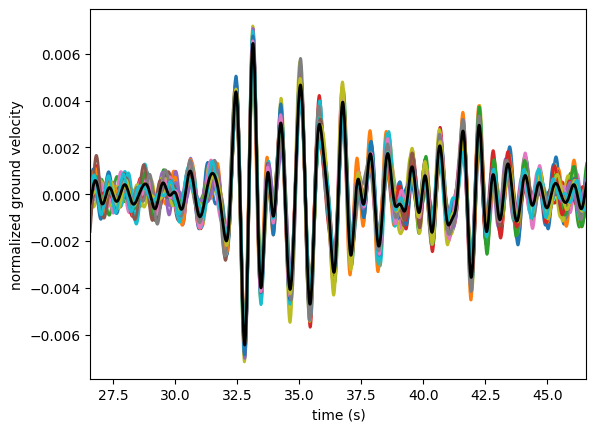

In [ ]:
# the trace with all the events in the early group
tr=lf.grpstk['early'].select(channel=chn,station=stn)[0]
print('Stack with all events is in lf.grpstk: ',tr)

# the bootstrapped stacks
stkb=lf.grpstkb['early']['.'.join([stn,chn])]
print('\nThere are bootstrapped stacks including subsets of the early events in lf.grpstkb[\'early\']: ',stkb.shape)

plt.plot(tr.times(),stkb,linewidth=2,label='bootstrapped');
plt.plot(tr.times(),tr.data,color='k',linewidth=2,label='full stack');
plt.xlim(np.array([-5,15])+tr.stats.t0);
plt.xlabel('time (s)');
plt.ylabel('normalized ground velocity');